In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv(r"C:\Users\Sufiyan\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 1 : Remove Unneccesary Feature 
* 1. Found customerID column that didn't make any impact 

In [4]:
df.drop(columns=["customerID"], inplace=True)

In [5]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 2 : Identify and Remove/Handle Duplicates and Null Values 

* 1. Found 22 Rows Duplicated

In [6]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.2,Yes


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# Step 3 : Handle Missing Values

* 1. Found TotalCharges have multiple " " empty space values 

In [9]:
df['TotalCharges'].value_counts()

TotalCharges
          11
19.75      9
20.2       8
19.65      7
19.9       7
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [10]:
for col in df.columns:
    print(f"Name : {col}\n")
    print(df[df[col] == " "])
    print("-"*50)

Name : gender

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
--------------------------------------------------
Name : SeniorCitizen

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
--------------------------------------------------
Name : Partner

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessB

In [11]:
df["TotalCharges"].replace({" " : "0"},inplace=True)

C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_12728\1031550559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].replace({" " : "0"},inplace=True)


In [12]:
df[df['TotalCharges'] == "0"]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0,No


# Step 4 :  Print unique values in all columns (spot typos/inconsistent categories)

* 1. Identified that TotalCharges has an incorrect data type.

In [13]:
# Categorical Feature
for col_name in df.select_dtypes("object"):
    print(f"Name : {col_name}")
    print(f"Unique Values - {df[col_name].unique()}")
    print("-"*50)

Name : gender
Unique Values - ['Female' 'Male']
--------------------------------------------------
Name : Partner
Unique Values - ['Yes' 'No']
--------------------------------------------------
Name : Dependents
Unique Values - ['No' 'Yes']
--------------------------------------------------
Name : PhoneService
Unique Values - ['No' 'Yes']
--------------------------------------------------
Name : MultipleLines
Unique Values - ['No phone service' 'No' 'Yes']
--------------------------------------------------
Name : InternetService
Unique Values - ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
Name : OnlineSecurity
Unique Values - ['No' 'Yes' 'No internet service']
--------------------------------------------------
Name : OnlineBackup
Unique Values - ['Yes' 'No' 'No internet service']
--------------------------------------------------
Name : DeviceProtection
Unique Values - ['No' 'Yes' 'No internet service']
--------------------------------------------------

In [14]:
# Numerical Feature
for col_name in df.select_dtypes("number"):
    print(f"Name : {col_name}")
    print(f"Unique Values - {df[col_name].unique()}")
    print("-"*50)

Name : SeniorCitizen
Unique Values - [0 1]
--------------------------------------------------
Name : tenure
Unique Values - [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
Name : MonthlyCharges
Unique Values - [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
--------------------------------------------------


# Step 5 : Fix Data Type

* 1. Found on Step 4 that TotalCharges is Object data type

In [15]:
df["TotalCharges"] = df['TotalCharges'].astype(float)

# Step 6 : Check Class Imbalance in Target Column (Churn)

* 1. Found Imbalance data in Churn No/Yes .73 / .26

In [16]:
df["Churn"].value_counts()/len(df['Churn']) * 100

Churn
No     73.550776
Yes    26.449224
Name: count, dtype: float64

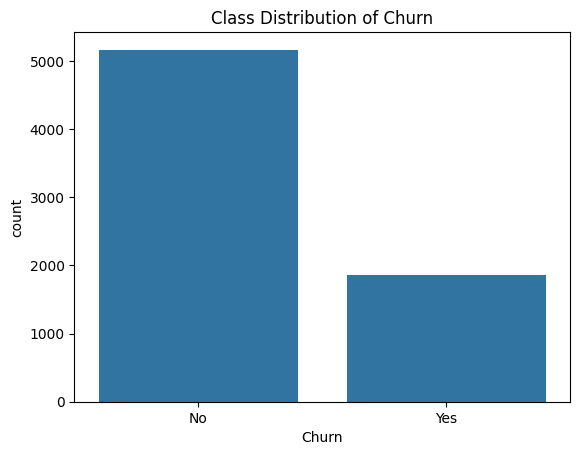

In [17]:
sb.countplot(data=df, x="Churn")
plt.title("Class Distribution of Churn")
plt.show()

# Step 7 : Distribution of Numerical Feature (Histogram and KDE)

In [18]:
def plot_histogram(df, col_name):
    plt.figure(figsize=(8,6))
    sb.histplot(df[col_name], kde=True)
    plt.title(f"Distribution of {col_name}")
    plt.show()

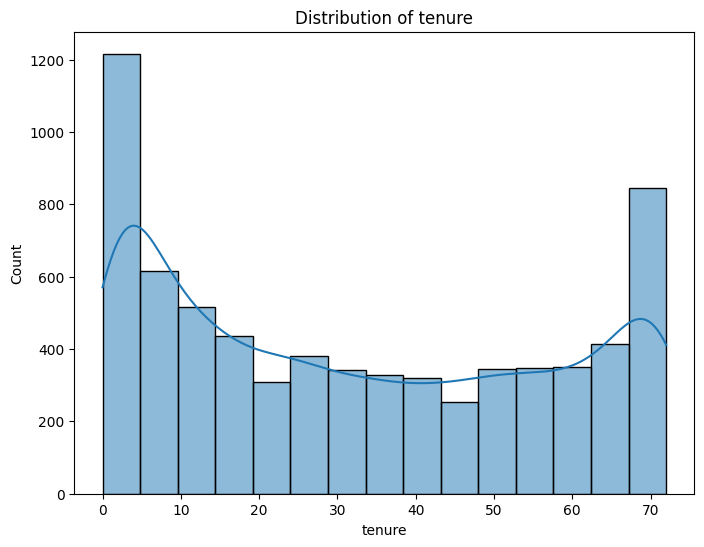

In [19]:
plot_histogram(df, "tenure")

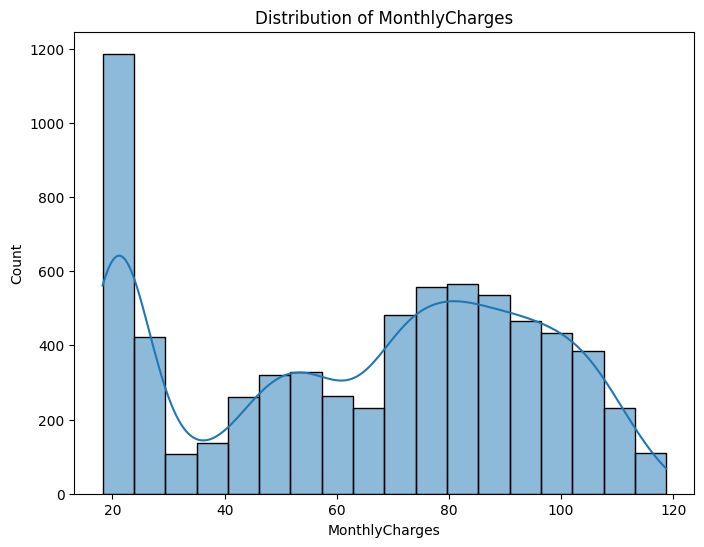

In [21]:
plot_histogram(df, "MonthlyCharges")

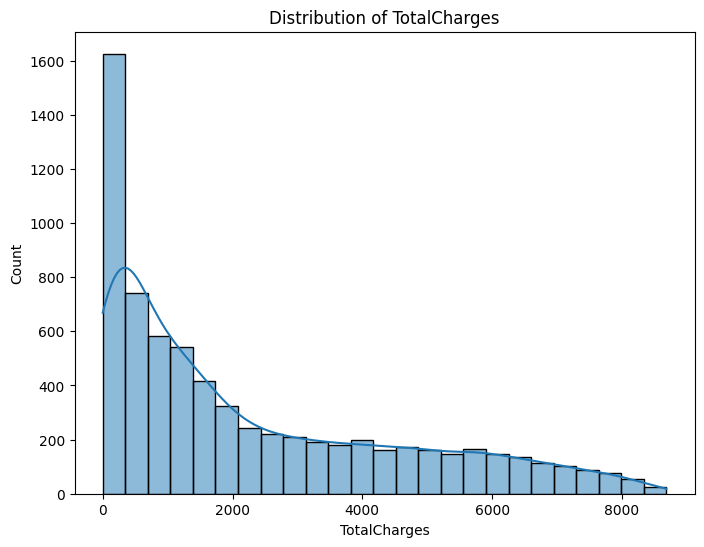

In [22]:
plot_histogram(df, "TotalCharges")

# Distribution Analysis of Numerical Features

* 1. Tenure Feature

    * Not normally distributed.
    * Bimodal/U-shaped distribution with peaks at both ends.
    * Highest concentration between 0–5 months.
    * Second peak around 65–72 months.
    * Lower frequency in the middle tenure range (20–50 months).
    * No obvious outliers, as tenure is naturally bounded between 0 and 72 months.

* 2. MonthlyCharges Feature

    * The distribution is not normally distributed.
    * Multiple peaks (multimodal) indicate distinct pricing segments.
    * Highest concentration around $20–30.
    * Another major concentration between $70–100.
    * Fewer customers have monthly charges between $30–70.
    * No obvious outliers, as the values fall within the expected pricing range (approximately $18–120).

* 3. TotalCharges Feature

    * The distribution is highly right-skewed (positively skewed).
    * Most customers have low total charges (approximately $0–$1,000).
    * The frequency decreases steadily as total charges increase.
    * A long right tail extends up to around $9,000.
    * No distinct secondary peaks, indicating a single dominant distribution.
    * No obvious outliers, as higher values are expected for long-term customers with higher monthly charges.

# Step 8 : Box plots for numerical features — check outliers

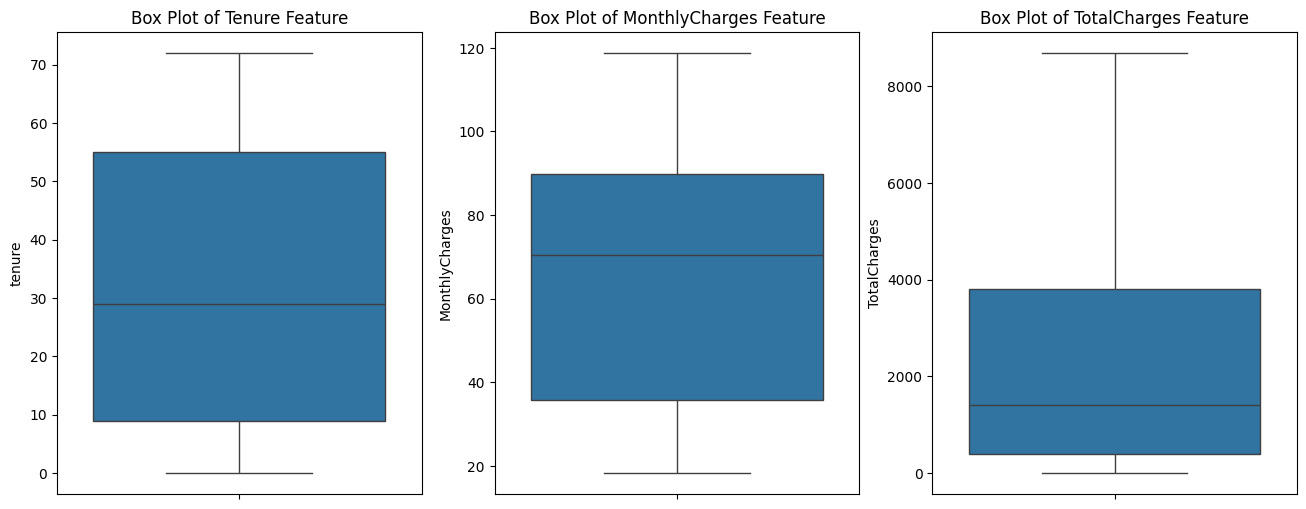

In [27]:
plt.figure(figsize=(16, 6))

plt.subplot(1,3,1)
sb.boxplot(data=df['tenure'])
plt.title("Box Plot of Tenure Feature")

plt.subplot(1,3,2)
sb.boxplot(data=df['MonthlyCharges'])
plt.title("Box Plot of MonthlyCharges Feature")

plt.subplot(1,3,3)
sb.boxplot(data=df['TotalCharges'])
plt.title("Box Plot of TotalCharges Feature")
plt.show()

# Conclusion 

* No significant outliers were detected in the numerical features based on the box plot analysis.

# Step 9 : Correlation heatmap for numerical features

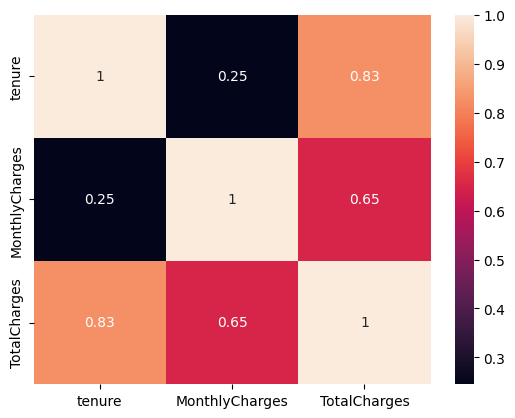

In [29]:
sb.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True,)
plt.show()

# Conclusion

* TotalCharges is strongly influenced by customer tenure and moderately influenced by monthly charges, while tenure and monthly charges have only a weak relationship.